In [14]:
import pandas as pd

df = pd.read_parquet("../data/processed/paysim_features.parquet")

# Rebuild time-bucket columns if they're missing after the reload
if "week_bucket" not in df.columns:
    df["week_bucket"] = (df["step"] - df["step"].min()) // (24 * 7)
if "day_bucket" not in df.columns:
    df["day_bucket"] = (df["step"] - df["step"].min()) // 24

print(f"Loaded {len(df):,} rows, {len(df.columns)} columns.")

Loaded 6,362,620 rows, 30 columns.


In [15]:
# 'type' (PAYMENT, TRANSFER, etc.) needs to be turned into separate 0/1
# columns before a model can use it. Only do this if it hasn't been
# done already, so re-running this cell doesn't break anything.
if "type" in df.columns:
    df = pd.get_dummies(df, columns=["type"], prefix="type")
    print("Encoded 'type' column.")

print("type_ columns present:", [c for c in df.columns if c.startswith("type_")])

type_ columns present: ['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [16]:
# These two columns have NaN wherever a destination account has no prior
# transactions to count within that time window. Missing history = zero
# prior transactions, so 0 is the correct value to fill in.
df["destination_transactions_last_24h"] = df["destination_transactions_last_24h"].fillna(0)
df["destination_transactions_last_7d"] = df["destination_transactions_last_7d"].fillna(0)

print("NaN values remaining:", df[["destination_transactions_last_24h", "destination_transactions_last_7d"]].isna().sum().sum())

NaN values remaining: 0


In [17]:
df.to_parquet("../data/processed/paysim_features.parquet", index=False)
print("Saved. Future notebook loads will already have these fixes.")

Saved. Future notebook loads will already have these fixes.


In [8]:
feature_columns = [
    "amount",
    "destination_transactions_last_24h",
    "destination_transactions_last_7d",
    "destination_avg_previous_amount",
    "destination_amount_deviation",
    "destination_is_first_transaction",
    "origin_balance_error",
    "destination_balance_error",
    "destination_balance_is_zero",
    "total_transactions",
    "total_transaction_amount",
    "avg_transaction_amount",
] + [c for c in df.columns if c.startswith("type_")]

target_column = "isFraud"

# Only days 5-16 have stable, trustworthy transaction volume (see earlier
# audit finding) — everything outside this range is too sparse to trust.
dense_window = df[(df["day_bucket"] >= 5) & (df["day_bucket"] <= 16)]

def get_dense_period(days):
    """Pull out features (X) and true fraud labels (y) for a list of days."""
    subset = dense_window[dense_window["day_bucket"].isin(days)]
    return subset[feature_columns], subset["isFraud"]

print(f"Using {len(feature_columns)} features.")
print(f"Dense window: {len(dense_window):,} rows.")

Using 17 features.
Dense window: 4,918,825 rows.


In [9]:
X_train, y_train = get_dense_period([5, 6, 7])       # train_initial
X_eval1, y_eval1 = get_dense_period([8, 9, 10])       # eval_1

print(f"Train: {len(X_train):,} rows, {y_train.sum():,} fraud cases")
print(f"Eval:  {len(X_eval1):,} rows, {y_eval1.sum():,} fraud cases")

Train: 1,311,225 rows, 778 fraud cases
Eval:  1,228,723 rows, 799 fraud cases


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score

baseline_model = LogisticRegression(max_iter=1000, class_weight="balanced")
baseline_model.fit(X_train, y_train)

pr_auc_baseline = average_precision_score(y_eval1, baseline_model.predict_proba(X_eval1)[:, 1])
print(f"Baseline PR-AUC: {pr_auc_baseline:.4f}")

KeyboardInterrupt: 

In [17]:
import lightgbm as lgb

# Default LightGBM settings let it build very deep, flexible trees —
# with only 778 fraud examples to learn from, that's enough freedom to
# memorize those specific rows instead of learning a pattern that
# generalizes. These settings deliberately limit that freedom.
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    num_leaves=15,
    max_depth=5,
    min_child_samples=100,
    reg_alpha=1.0,
    reg_lambda=1.0,
    scale_pos_weight=20,
    random_state=42
)
lgb_model.fit(X_train, y_train)

pr_auc_lgb_train = average_precision_score(y_train, lgb_model.predict_proba(X_train)[:, 1])
pr_auc_lgb_eval = average_precision_score(y_eval1, lgb_model.predict_proba(X_eval1)[:, 1])

print(f"LightGBM PR-AUC on TRAINING data: {pr_auc_lgb_train:.4f}")
print(f"LightGBM PR-AUC on eval_1:        {pr_auc_lgb_eval:.4f}")
print(f"Baseline PR-AUC (for comparison): {pr_auc_baseline:.4f}")

[LightGBM] [Info] Number of positive: 778, number of negative: 1310447
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013425 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1563
[LightGBM] [Info] Number of data points in the train set: 1311225, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000593 -> initscore=-7.429152
[LightGBM] [Info] Start training from score -7.429152
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [18]:
X_eval2, y_eval2 = get_dense_period([11, 12, 13])
X_held_out, y_held_out = get_dense_period([14, 15, 16])

pr_auc_eval2 = average_precision_score(y_eval2, lgb_model.predict_proba(X_eval2)[:, 1])
pr_auc_held_out = average_precision_score(y_held_out, lgb_model.predict_proba(X_held_out)[:, 1])

print(f"LightGBM PR-AUC on eval_1 (days 8-10):    {pr_auc_lgb_eval:.4f}")
print(f"LightGBM PR-AUC on eval_2 (days 11-13):   {pr_auc_eval2:.4f}")
print(f"LightGBM PR-AUC on held_out (days 14-16): {pr_auc_held_out:.4f}")

LightGBM PR-AUC on eval_1 (days 8-10):    0.7113
LightGBM PR-AUC on eval_2 (days 11-13):   0.7252
LightGBM PR-AUC on held_out (days 14-16): 0.7198


In [19]:
import numpy as np

def bootstrap_pr_auc(model, X, y, n_bootstrap=200, seed=42):
    """
    Resample the evaluation set with replacement many times, computing
    PR-AUC each time, to see how much this metric naturally wobbles
    just from which specific examples happen to be in the sample.
    """
    rng = np.random.RandomState(seed)
    scores = []
    y_reset = y.reset_index(drop=True)
    X_reset = X.reset_index(drop=True)
    n = len(y_reset)
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        y_sample = y_reset.iloc[idx]
        # Skip resamples with no fraud cases at all — PR-AUC undefined
        if y_sample.sum() == 0:
            continue
        X_sample = X_reset.iloc[idx]
        preds = model.predict_proba(X_sample)[:, 1]
        scores.append(average_precision_score(y_sample, preds))
    return np.array(scores)

for name, X, y in [("eval_1", X_eval1, y_eval1), ("eval_2", X_eval2, y_eval2), ("held_out", X_held_out, y_held_out)]:
    scores = bootstrap_pr_auc(lgb_model, X, y)
    lower, upper = np.percentile(scores, [2.5, 97.5])
    print(f"{name}: PR-AUC = {scores.mean():.4f}, 95% CI = [{lower:.4f}, {upper:.4f}]")

eval_1: PR-AUC = 0.7105, 95% CI = [0.6772, 0.7378]
eval_2: PR-AUC = 0.7257, 95% CI = [0.6936, 0.7664]


KeyboardInterrupt: 

In [ ]:
# Retrained model: original training period (5-7) PLUS the first eval
# period (8-10) combined, simulating "we got new data and retrained."
X_retrain, y_retrain = get_dense_period([5, 6, 7, 8, 9, 10])

lgb_model_retrained = lgb.LGBMClassifier(
    n_estimators=200,
    num_leaves=15,
    max_depth=5,
    min_child_samples=100,
    reg_alpha=1.0,
    reg_lambda=1.0,
    scale_pos_weight=20,
    random_state=42,
    verbose=-1  # suppress the repetitive warning messages this time
)
lgb_model_retrained.fit(X_retrain, y_retrain)

pr_auc_retrained_held_out = average_precision_score(
    y_held_out, lgb_model_retrained.predict_proba(X_held_out)[:, 1]
)

print(f"Original model (trained days 5-7) on held_out:     {pr_auc_held_out:.4f}")
print(f"Retrained model (trained days 5-10) on held_out:   {pr_auc_retrained_held_out:.4f}")
print(f"Difference:                                        {pr_auc_retrained_held_out - pr_auc_held_out:+.4f}")

Original model (trained days 5-7) on held_out:     0.8252
Retrained model (trained days 5-10) on held_out:   0.8046
Difference:                                        -0.0206


In [ ]:
import numpy as np
from sklearn.metrics import average_precision_score

def bootstrap_pr_auc_fast(model, X, y, n_bootstrap=200, seed=42):
    y_reset = y.reset_index(drop=True).values
    preds = model.predict_proba(X)[:, 1]  # computed once, not per-resample

    rng = np.random.RandomState(seed)
    n = len(y_reset)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        y_sample = y_reset[idx]
        if y_sample.sum() == 0:
            continue
        pred_sample = preds[idx]
        scores.append(average_precision_score(y_sample, pred_sample))
    return np.array(scores)

print("Function defined.")

Function defined.


In [ ]:
scores_retrained = bootstrap_pr_auc_fast(lgb_model_retrained, X_held_out, y_held_out)
lower_r, upper_r = np.percentile(scores_retrained, [2.5, 97.5])

print(f"Original model on held_out:  PR-AUC = {pr_auc_held_out:.4f}, 95% CI = [{lower:.4f}, {upper:.4f}]")
print(f"Retrained model on held_out: PR-AUC = {pr_auc_retrained_held_out:.4f}, 95% CI = [{lower_r:.4f}, {upper_r:.4f}]")

Original model on held_out:  PR-AUC = 0.8252, 95% CI = [0.8008, 0.8484]
Retrained model on held_out: PR-AUC = 0.8046, 95% CI = [0.7769, 0.8315]


In [ ]:
import numpy as np
from scipy.stats import ks_2samp

def calculate_psi(expected, actual, buckets=10):
    """
    PSI compares two distributions using the same bin edges (derived from
    the 'expected'/reference distribution). Values > 0.25 = major shift,
    0.1-0.25 = moderate, < 0.1 = stable. Sample-size independent, unlike
    p-values — this is the primary metric to trust.
    """
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf
    breakpoints = np.unique(breakpoints)

    expected_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_pct = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)

    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi

def feature_drift_report(X_ref, X_compare, feature_list):
    rows = []
    for feat in feature_list:
        psi = calculate_psi(X_ref[feat].values, X_compare[feat].values)
        ks_stat, ks_p = ks_2samp(X_ref[feat], X_compare[feat])
        rows.append({"feature": feat, "psi": psi, "ks_stat": ks_stat, "ks_pvalue": ks_p})
    return pd.DataFrame(rows).sort_values("psi", ascending=False)

In [ ]:
X_train_initial, y_train_initial = get_dense_period([5, 6, 7])

numeric_features = [f for f in feature_columns if not f.startswith("type_") and f != "destination_is_first_transaction" and f != "destination_balance_is_zero"]

print("=== Feature drift: train_initial vs eval_1 ===")
print(feature_drift_report(X_train_initial, X_eval1, numeric_features))

print("\n=== Feature drift: train_initial vs eval_2 ===")
print(feature_drift_report(X_train_initial, X_eval2, numeric_features))

print("\n=== Feature drift: train_initial vs held_out ===")
print(feature_drift_report(X_train_initial, X_held_out, numeric_features))

=== Feature drift: train_initial vs eval_1 ===
                             feature       psi   ks_stat      ks_pvalue
9             avg_transaction_amount  1.815109  0.325254   0.000000e+00
8           total_transaction_amount  1.733372  0.364233   0.000000e+00
7                 total_transactions  0.519440  0.186425   0.000000e+00
0                             amount  0.008717  0.026636   0.000000e+00
6          destination_balance_error  0.007333  0.025338   0.000000e+00
5               origin_balance_error  0.004368  0.024106  1.083980e-320
4       destination_amount_deviation  0.002785  0.021933  1.687482e-265
3    destination_avg_previous_amount  0.000149  0.005531   2.784403e-17
2   destination_transactions_last_7d  0.000040  0.001879   2.265896e-02
1  destination_transactions_last_24h  0.000014  0.001282   2.483186e-01

=== Feature drift: train_initial vs eval_2 ===
                             feature       psi   ks_stat      ks_pvalue
8           total_transaction_amount  3.6

In [ ]:
print("\n=== Transaction type proportions across periods ===")
for name, X in [("train_initial", X_train_initial), ("eval_1", X_eval1), ("eval_2", X_eval2), ("held_out", X_held_out)]:
    type_cols = [c for c in feature_columns if c.startswith("type_")]
    proportions = X[type_cols].mean()
    print(f"\n{name}:")
    print(proportions)


=== Transaction type proportions across periods ===

train_initial:
type_CASH_IN     0.223936
type_CASH_OUT    0.358674
type_DEBIT       0.006175
type_PAYMENT     0.328308
type_TRANSFER    0.082906
dtype: float64

eval_1:
type_CASH_IN     0.216710
type_CASH_OUT    0.353854
type_DEBIT       0.005363
type_PAYMENT     0.342036
type_TRANSFER    0.082036
dtype: float64

eval_2:
type_CASH_IN     0.218997
type_CASH_OUT    0.350282
type_DEBIT       0.006547
type_PAYMENT     0.340426
type_TRANSFER    0.083748
dtype: float64

held_out:
type_CASH_IN     0.220948
type_CASH_OUT    0.352495
type_DEBIT       0.007120
type_PAYMENT     0.335497
type_TRANSFER    0.083940
dtype: float64


In [ ]:
X_train_fraud = X_train_initial[y_train_initial == 1]
X_eval1_fraud = X_eval1[y_eval1 == 1]
X_eval2_fraud = X_eval2[y_eval2 == 1]
X_held_out_fraud = X_held_out[y_held_out == 1]

print("=== Fraud-only feature drift: train_initial vs held_out ===")
print(feature_drift_report(X_train_fraud, X_held_out_fraud, numeric_features))

=== Fraud-only feature drift: train_initial vs held_out ===
                             feature       psi   ks_stat      ks_pvalue
2   destination_transactions_last_7d  6.954767  0.809769  1.073334e-263
3    destination_avg_previous_amount  6.801296  0.852185  7.878196e-299
1  destination_transactions_last_24h  4.677464  0.557841  4.573999e-115
4       destination_amount_deviation  1.538112  0.246787   7.111257e-22
9             avg_transaction_amount  0.936744  0.268985   6.012556e-26
7                 total_transactions  0.794990  0.157119   4.337513e-09
8           total_transaction_amount  0.222657  0.100914   5.266285e-04
0                             amount  0.091596  0.056815   1.437793e-01
6          destination_balance_error  0.016408  0.033976   7.270798e-01
5               origin_balance_error  0.000761  0.004729   1.000000e+00


In [ ]:
scores_train = lgb_model.predict_proba(X_train_initial)[:, 1]
scores_eval1 = lgb_model.predict_proba(X_eval1)[:, 1]
scores_eval2 = lgb_model.predict_proba(X_eval2)[:, 1]
scores_held_out = lgb_model.predict_proba(X_held_out)[:, 1]

print("Score PSI (train_initial as reference):")
print(f"  eval_1:    {calculate_psi(scores_train, scores_eval1):.4f}")
print(f"  eval_2:    {calculate_psi(scores_train, scores_eval2):.4f}")
print(f"  held_out:  {calculate_psi(scores_train, scores_held_out):.4f}")

Score PSI (train_initial as reference):
  eval_1:    0.0016
  eval_2:    0.0407
  held_out:  0.0198


In [ ]:
def precision_at_k(y_true, y_scores, k_fraction=0.01):
    n = len(y_true)
    k = max(1, int(n * k_fraction))
    top_k_idx = np.argsort(y_scores)[-k:]
    y_true_arr = np.array(y_true)
    return y_true_arr[top_k_idx].sum() / k

for name, y, scores in [("eval_1", y_eval1, scores_eval1), ("eval_2", y_eval2, scores_eval2), ("held_out", y_held_out, scores_held_out)]:
    p_at_1pct = precision_at_k(y, scores, 0.01)
    print(f"{name}: precision@1% = {p_at_1pct:.4f}")

eval_1: precision@1% = 0.0610
eval_2: precision@1% = 0.0628
held_out: precision@1% = 0.0639


In [ ]:
import shap

explainer = shap.TreeExplainer(lgb_model)

def get_shap_importance(X, sample_size=5000, seed=42):
    X_sample = X.sample(n=min(sample_size, len(X)), random_state=seed)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):  # some LightGBM versions return a list for binary classification
        shap_values = shap_values[1]
    importance = np.abs(shap_values).mean(axis=0)
    return pd.Series(importance, index=X.columns).sort_values(ascending=False)

shap_train = get_shap_importance(X_train_initial)
shap_held_out = get_shap_importance(X_held_out)

print("SHAP importance — train_initial:")
print(shap_train.head(10))
print("\nSHAP importance — held_out:")
print(shap_held_out.head(10))

from scipy.stats import spearmanr
common_features = shap_train.index
rank_corr, _ = spearmanr(shap_train[common_features], shap_held_out[common_features])
print(f"\nSpearman rank correlation of feature importance (train_initial vs held_out): {rank_corr:.4f}")
print("(Close to 1.0 = feature importance ranking stayed stable; lower = the model shifted what it relies on.)")

c:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\fraud_env\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP importance — train_initial:
origin_balance_error                1.981124
destination_balance_error           1.920088
type_CASH_OUT                       1.850094
amount                              1.524811
type_TRANSFER                       0.627929
type_PAYMENT                        0.489726
destination_balance_is_zero         0.423826
destination_amount_deviation        0.232541
destination_avg_previous_amount     0.218897
destination_transactions_last_7d    0.216907
dtype: float64

SHAP importance — held_out:
origin_balance_error               1.914066
destination_balance_error          1.870757
type_CASH_OUT                      1.814407
amount                             1.480105
type_TRANSFER                      0.643797
type_PAYMENT                       0.507730
destination_balance_is_zero        0.438801
total_transactions                 0.255099
total_transaction_amount           0.228323
destination_avg_previous_amount    0.221694
dtype: float64

Spearman rank cor

c:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\fraud_env\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [ ]:
feature_psi = feature_drift_report(X_train_initial, X_held_out, numeric_features).set_index("feature")["psi"]

combined = pd.DataFrame({
    "psi_vs_held_out": feature_psi,
    "shap_importance_train": shap_train.reindex(feature_psi.index)
}).dropna()

combined["monitoring_priority"] = combined["psi_vs_held_out"] * combined["shap_importance_train"]
combined = combined.sort_values("monitoring_priority", ascending=False)

print("Features to prioritize for monitoring (high drift AND high importance):")
print(combined)

Features to prioritize for monitoring (high drift AND high importance):
                                   psi_vs_held_out  shap_importance_train  \
feature                                                                     
destination_avg_previous_amount           7.287878               0.218897   
destination_transactions_last_7d          7.079532               0.216907   
destination_amount_deviation              4.847146               0.232541   
total_transactions                        2.310110               0.186867   
destination_transactions_last_24h         4.880964               0.073098   
avg_transaction_amount                    1.652682               0.133676   
total_transaction_amount                  0.263274               0.201637   
destination_balance_error                 0.011964               1.920088   
amount                                    0.005999               1.524811   
origin_balance_error                      0.003693               1.981124   

   

In [ ]:
X_sparse, y_sparse = get_period_data if False else (None, None)  # placeholder guard

sparse_subset = df[df["day_bucket"].isin([25, 26, 27])]
X_sparse = sparse_subset[feature_columns]
y_sparse = sparse_subset["isFraud"]

print(f"Sparse period (days 25-27): {len(X_sparse):,} rows, {y_sparse.sum():,} fraud cases")
print("CAUTION: low transaction volume — treat this as a secondary, low-confidence check only.")

if y_sparse.sum() > 5:  # need at least a handful of fraud cases for PR-AUC to mean anything
    pr_auc_sparse = average_precision_score(y_sparse, lgb_model.predict_proba(X_sparse)[:, 1])
    print(f"PR-AUC on sparse period: {pr_auc_sparse:.4f} (compare cautiously to held_out's {pr_auc_held_out:.4f})")
else:
    print("Too few fraud cases in this period to compute a meaningful PR-AUC.")

Sparse period (days 25-27): 37,124 rows, 800 fraud cases
CAUTION: low transaction volume — treat this as a secondary, low-confidence check only.
PR-AUC on sparse period: 0.9331 (compare cautiously to held_out's 0.8252)


In [ ]:
sparse_fraud_rate = y_sparse.sum() / len(y_sparse) * 100
print(f"Sparse period (days 25-27) fraud rate: {sparse_fraud_rate:.4f}%")
print(f"Dense window fraud rates for comparison: eval_1={y_eval1.sum()/len(y_eval1)*100:.4f}%, held_out={y_held_out.sum()/len(y_held_out)*100:.4f}%")

Sparse period (days 25-27) fraud rate: 2.1549%
Dense window fraud rates for comparison: eval_1=0.0650%, held_out=0.0683%


In [ ]:
X_train[["total_transactions", "total_transaction_amount", "avg_transaction_amount"]].describe()

,total_transactions,total_transaction_amount,avg_transaction_amount
count,1.311225e+06,1.311225e+06,1.311225e+06
mean,3.206965e+04,5.166709e+09,1.605456e+05
std,9.425851e+03,1.527120e+09,3.068368e+04
min,4.000000e+00,2.700001e+06,9.294349e+04
25%,2.820400e+04,4.692443e+09,1.478228e+05
50%,3.190000e+04,5.233469e+09,1.640586e+05
75%,3.732300e+04,6.199143e+09,1.791496e+05
max,4.908300e+04,7.391259e+09,5.519345e+06


In [20]:
print(lgb_model.n_features_)
print(lgb_model.feature_name_)

17
['amount', 'destination_transactions_last_24h', 'destination_transactions_last_7d', 'destination_avg_previous_amount', 'destination_amount_deviation', 'destination_is_first_transaction', 'origin_balance_error', 'destination_balance_error', 'destination_balance_is_zero', 'total_transactions', 'total_transaction_amount', 'avg_transaction_amount', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [25]:
import joblib

joblib.dump(
    lgb_model,
    r"C:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\models\fraud_model.pkl"
)

['C:\\Users\\Anushka\\OneDrive\\Desktop\\fraud-detection-project\\models\\fraud_model.pkl']

In [26]:
fraud_df = df[df["isFraud"] == 1]
print(fraud_df["amount"].describe())
print(fraud_df["amount"].value_counts(bins=10))

count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64
(-10000.001, 1000000.0]    5507
(1000000.0, 2000000.0]     1026
(2000000.0, 3000000.0]      507
(9000000.0, 10000000.0]     344
(3000000.0, 4000000.0]      263
(4000000.0, 5000000.0]      166
(5000000.0, 6000000.0]      125
(7000000.0, 8000000.0]      105
(6000000.0, 7000000.0]      102
(8000000.0, 9000000.0]       68
Name: count, dtype: int64


In [35]:
eval_probs = lgb_model.predict_proba(X_held_out)[:, 1]
eval_actual = y_held_out.values if hasattr(y_held_out, "values") else y_held_out

results = pd.DataFrame({
    "amount": X_held_out["amount"].values,
    "actual_fraud": eval_actual,
    "predicted_prob": eval_probs,
})

bins = [0, 127091, 441423, 1517771, 10_000_001]
labels = ["0-127K (Q1)", "127K-441K (Q2)", "441K-1.5M (Q3)", "1.5M-10M (Q4)"]
results["amount_bucket"] = pd.cut(results["amount"], bins=bins, labels=labels)

T_BLOCK = 0.90
T_REVIEW = 0.0001

def compute_recall(group):
    fraud_rows = group[group["actual_fraud"] == 1]
    if len(fraud_rows) == 0:
        return pd.Series({"n_fraud": 0, "recall_at_block": np.nan, "recall_at_review": np.nan})
    caught_block = (fraud_rows["predicted_prob"] >= T_BLOCK).sum()
    caught_review = (fraud_rows["predicted_prob"] >= T_REVIEW).sum()
    return pd.Series({
        "n_fraud": len(fraud_rows),
        "recall_at_block": caught_block / len(fraud_rows),
        "recall_at_review": caught_review / len(fraud_rows),
    })

recall_by_bucket = results.groupby("amount_bucket", observed=True).apply(compute_recall)
print(recall_by_bucket)

                n_fraud  recall_at_block  recall_at_review
amount_bucket                                             
0-127K (Q1)       200.0         0.635000          0.975000
127K-441K (Q2)    206.0         0.655340          0.927184
441K-1.5M (Q3)    190.0         0.847368          0.968421
1.5M-10M (Q4)     225.0         0.960000          0.968889


In [38]:
test_amounts = list(range(5000, 500000, 15000)) + list(range(500000, 10000000, 250000))

sweep_results = []
for amt in test_amounts:
    row = pd.DataFrame([{
        'amount': amt,
        'destination_transactions_last_24h': 0,
        'destination_transactions_last_7d': 0,
        'destination_avg_previous_amount': 0,
        'destination_amount_deviation': amt,
        'destination_is_first_transaction': 1,
        'origin_balance_error': 0,
        'destination_balance_error': amt,
        'destination_balance_is_zero': 1,
        'total_transactions': 31900,
        'total_transaction_amount': 5233469000,
        'avg_transaction_amount': 164058.6,
        'type_CASH_IN': False, 'type_CASH_OUT': True, 'type_DEBIT': False,
        'type_PAYMENT': False, 'type_TRANSFER': False,
    }])[feature_columns]
    prob = lgb_model.predict_proba(row)[:, 1][0]
    sweep_results.append({"amount": amt, "prob": prob})

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df)

     amount      prob
0      5000  0.018843
1     20000  0.018843
2     35000  0.017268
3     50000  0.042748
4     65000  0.017580
..      ...       ...
66  8750000  1.000000
67  9000000  1.000000
68  9250000  1.000000
69  9500000  1.000000
70  9750000  1.000000

[71 rows x 2 columns]


In [39]:
# find where probability crosses key thresholds
print(sweep_df[(sweep_df["prob"] >= 0.01) & (sweep_df["prob"] <= 0.99)])

# check monotonicity - flag any amount where prob DROPS compared to a smaller amount
sweep_df["prob_diff"] = sweep_df["prob"].diff()
print("\nRows where probability decreased vs. previous (smaller) amount:")
print(sweep_df[sweep_df["prob_diff"] < -0.01])

     amount      prob
0      5000  0.018843
1     20000  0.018843
2     35000  0.017268
3     50000  0.042748
4     65000  0.017580
5     80000  0.017580
6     95000  0.222247
7    110000  0.235882
8    125000  0.190834
34   750000  0.972469
35  1000000  0.336664

Rows where probability decreased vs. previous (smaller) amount:
     amount          prob  prob_diff
4     65000  1.757954e-02  -0.025168
8    125000  1.908342e-01  -0.045048
9    140000  4.939666e-07  -0.190834
24   365000  1.470550e-09  -1.000000
29   440000  5.404927e-03  -0.994595
35  1000000  3.366640e-01  -0.635805


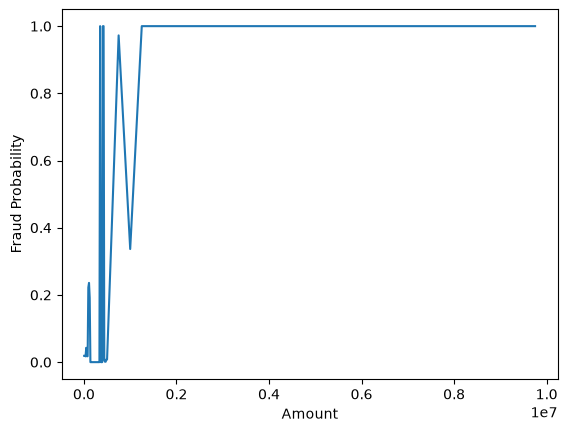

In [40]:
import matplotlib.pyplot as plt
plt.plot(sweep_df["amount"], sweep_df["prob"])
plt.xlabel("Amount")
plt.ylabel("Fraud Probability")
plt.show()

In [41]:
real_fraud_midrange = X_held_out[
    (y_held_out == 1) &
    (X_held_out["amount"] >= 300000) &
    (X_held_out["amount"] <= 1000000)
].copy()

real_fraud_midrange["predicted_prob"] = lgb_model.predict_proba(real_fraud_midrange[feature_columns])[:, 1]
print(real_fraud_midrange[["amount", "destination_balance_error", "destination_amount_deviation", "predicted_prob"]].sort_values("amount"))

            amount  destination_balance_error  destination_amount_deviation  \
5212334  310726.29                       0.00                  34355.081667   
5212333  310726.29                  310726.29                 310726.290000   
5975515  312955.14                  312955.14                 312955.140000   
5975516  312955.14                       0.00                 202979.946667   
5980628  313936.67                  313936.67                 313936.670000   
...            ...                        ...                           ...   
5946941  973805.75                  973805.75                 973805.750000   
4902606  977805.62                       0.00                 977805.620000   
4902605  977805.62                  977805.62                 977805.620000   
5563206  978362.97                  978362.97                 978362.970000   
5563207  978362.97                       0.00                 786259.335000   

         predicted_prob  
5212334        0.163888  

In [42]:
# One clean, legitimate transaction (low fraud probability)
legit_candidates = X_held_out[y_held_out == 0].copy()
legit_candidates["predicted_prob"] = lgb_model.predict_proba(legit_candidates[feature_columns])[:, 1]
legit_example = legit_candidates[legit_candidates["predicted_prob"] < 0.001].sample(1, random_state=42)
print("LEGIT EXAMPLE:")
print(legit_example[feature_columns].to_dict(orient="records"))

# Three real fraud examples, one from each amount tier
fraud_candidates = X_held_out[y_held_out == 1].copy()
fraud_candidates["predicted_prob"] = lgb_model.predict_proba(fraud_candidates[feature_columns])[:, 1]

low_fraud = fraud_candidates[(fraud_candidates["amount"] < 200000) & (fraud_candidates["predicted_prob"] > 0.9)].sample(1, random_state=42)
mid_fraud = fraud_candidates[(fraud_candidates["amount"] >= 400000) & (fraud_candidates["amount"] < 800000) & (fraud_candidates["predicted_prob"] > 0.9)].sample(1, random_state=42)
high_fraud = fraud_candidates[(fraud_candidates["amount"] >= 2000000) & (fraud_candidates["predicted_prob"] > 0.9)].sample(1, random_state=42)

print("\nLOW-AMOUNT FRAUD EXAMPLE:")
print(low_fraud[feature_columns].to_dict(orient="records"))
print("\nMID-AMOUNT FRAUD EXAMPLE:")
print(mid_fraud[feature_columns].to_dict(orient="records"))
print("\nHIGH-AMOUNT FRAUD EXAMPLE:")
print(high_fraud[feature_columns].to_dict(orient="records"))

LEGIT EXAMPLE:
[{'amount': 76431.17, 'destination_transactions_last_24h': 1.0, 'destination_transactions_last_7d': 11.0, 'destination_avg_previous_amount': 391891.7783333333, 'destination_amount_deviation': -315460.60833333334, 'destination_is_first_transaction': 0, 'origin_balance_error': -76431.17, 'destination_balance_error': 0.0, 'destination_balance_is_zero': 0, 'total_transactions': 33528, 'total_transaction_amount': 4693535568.26, 'avg_transaction_amount': 139988.53400918635, 'type_CASH_IN': False, 'type_CASH_OUT': True, 'type_DEBIT': False, 'type_PAYMENT': False, 'type_TRANSFER': False}]

LOW-AMOUNT FRAUD EXAMPLE:
[{'amount': 48266.8, 'destination_transactions_last_24h': 0.0, 'destination_transactions_last_7d': 0.0, 'destination_avg_previous_amount': 0.0, 'destination_amount_deviation': 48266.8, 'destination_is_first_transaction': 1, 'origin_balance_error': 0.0, 'destination_balance_error': 48266.8, 'destination_balance_is_zero': 1, 'total_transactions': 40218, 'total_transacti

In [10]:
import numpy as np

# change random_state each run (or remove it) for a genuinely new random sample every time
sample = X_held_out.sample(n=20, random_state=None)
sample_labels = y_held_out.loc[sample.index]

sample_probs = lgb_model.predict_proba(sample[feature_columns])[:, 1]

T_REVIEW = 0.0001
T_BLOCK = 0.90

def tier_from_prob(p):
    if p >= T_BLOCK:
        return "BLOCK"
    elif p >= T_REVIEW:
        return "REVIEW"
    return "ALLOW"

results = pd.DataFrame({
    "amount": sample["amount"].values,
    "actual_fraud": sample_labels.values,
    "predicted_prob": sample_probs,
    "predicted_tier": [tier_from_prob(p) for p in sample_probs],
})

# "Caught" = model didn't ALLOW an actual fraud through
results["correctly_flagged"] = ~((results["actual_fraud"] == 1) & (results["predicted_tier"] == "ALLOW"))
results["false_alarm"] = (results["actual_fraud"] == 0) & (results["predicted_tier"] != "ALLOW")

print(results)
print(f"\nFraud caught (not ALLOWed): {results[results['actual_fraud']==1]['correctly_flagged'].sum()} / {(results['actual_fraud']==1).sum()}")
print(f"False alarms on legit txns: {results['false_alarm'].sum()} / {(results['actual_fraud']==0).sum()}")

NameError: name 'X_held_out' is not defined

In [11]:
%whos

Variable           Type         Data/Info
-----------------------------------------
X_eval1            DataFrame    Shape: (1228723, 17)
X_train            DataFrame    Shape: (1311225, 17)
dense_window       DataFrame    Shape: (4918825, 30)
df                 DataFrame    Shape: (6362620, 30)
feature_columns    list         n=17
get_dense_period   function     <function get_dense_period at 0x00000195E82251C0>
np                 module       <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
pd                 module       <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
target_column      str          isFraud
y_eval1            Series       Shape: (1228723,)
y_train            Series       Shape: (1311225,)


In [19]:
import joblib
lgb_model = joblib.load(r"C:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\models\fraud_model_full.pkl")
X_held_out, y_held_out = joblib.load(r"C:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\models\held_out_data.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Anushka\\OneDrive\\Desktop\\fraud-detection-project\\models\\fraud_model_full.pkl'

In [20]:
%whos

Variable                  Type                  Data/Info
---------------------------------------------------------
LogisticRegression        type                  <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
X_eval1                   DataFrame             Shape: (1228723, 17)
X_train                   DataFrame             Shape: (1311225, 17)
average_precision_score   function              <function average_precisi<...>re at 0x00000195C3C6A2A0>
baseline_model            LogisticRegression    LogisticRegression(class_<...>balanced', max_iter=1000)
dense_window              DataFrame             Shape: (4918825, 30)
df                        DataFrame             Shape: (6362620, 30)
feature_columns           list                  n=17
get_dense_period          function              <function get_dense_period at 0x00000195E82251C0>
joblib                    module                <module 'joblib' from 'c:<...>es\\joblib\\__init__.py'>
np                        module         

In [21]:
import joblib
lgb_model, = [joblib.load(r"C:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\models\fraud_model_full.pkl")]
X_held_out, y_held_out = joblib.load(r"C:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\models\held_out_data.pkl")

In [22]:
sample = X_held_out.sample(n=200, random_state=None)
sample_labels = y_held_out.loc[sample.index]

sample_probs = lgb_model.predict_proba(sample[feature_columns])[:, 1]

T_REVIEW = 0.0001
T_BLOCK = 0.90

def tier_from_prob(p):
    if p >= T_BLOCK:
        return "BLOCK"
    elif p >= T_REVIEW:
        return "REVIEW"
    return "ALLOW"

results = pd.DataFrame({
    "amount": sample["amount"].values,
    "actual_fraud": sample_labels.values,
    "predicted_prob": sample_probs,
    "predicted_tier": [tier_from_prob(p) for p in sample_probs],
})

results["correctly_flagged"] = ~((results["actual_fraud"] == 1) & (results["predicted_tier"] == "ALLOW"))
results["false_alarm"] = (results["actual_fraud"] == 0) & (results["predicted_tier"] != "ALLOW")

n_fraud = (results["actual_fraud"] == 1).sum()
n_legit = (results["actual_fraud"] == 0).sum()
print(f"Fraud caught (not ALLOWed): {results[results['actual_fraud']==1]['correctly_flagged'].sum()} / {n_fraud}")
print(f"False alarms on legit txns: {results['false_alarm'].sum()} / {n_legit}")

Fraud caught (not ALLOWed): 0 / 0
False alarms on legit txns: 8 / 200


In [23]:
sample = X_held_out.sample(n=5000, random_state=None)

In [24]:
sample_labels = y_held_out.loc[sample.index]
sample_probs = lgb_model.predict_proba(sample[feature_columns])[:, 1]

T_REVIEW = 0.0001
T_BLOCK = 0.90

def tier_from_prob(p):
    if p >= T_BLOCK:
        return "BLOCK"
    elif p >= T_REVIEW:
        return "REVIEW"
    return "ALLOW"

results = pd.DataFrame({
    "amount": sample["amount"].values,
    "actual_fraud": sample_labels.values,
    "predicted_prob": sample_probs,
    "predicted_tier": [tier_from_prob(p) for p in sample_probs],
})

results["correctly_flagged"] = ~((results["actual_fraud"] == 1) & (results["predicted_tier"] == "ALLOW"))
results["false_alarm"] = (results["actual_fraud"] == 0) & (results["predicted_tier"] != "ALLOW")

n_fraud = (results["actual_fraud"] == 1).sum()
n_legit = (results["actual_fraud"] == 0).sum()
print(f"Fraud caught (not ALLOWed): {results[results['actual_fraud']==1]['correctly_flagged'].sum()} / {n_fraud}")
print(f"False alarms on legit txns: {results['false_alarm'].sum()} / {n_legit}")

Fraud caught (not ALLOWed): 7 / 7
False alarms on legit txns: 200 / 4993


In [25]:
false_alarm_rows = results[results["false_alarm"]]
print(false_alarm_rows["predicted_tier"].value_counts())

predicted_tier
REVIEW    200
Name: count, dtype: int64


In [26]:
import pandas as pd

# Pull a decent-sized, class-balanced sample so random draws reliably
# surface both fraud and legit cases, not just legit by base-rate luck
demo_fraud = X_held_out[y_held_out == 1].sample(n=100, random_state=1)
demo_legit = X_held_out[y_held_out == 0].sample(n=400, random_state=1)

demo_sample = pd.concat([demo_fraud, demo_legit]).reset_index(drop=True)
demo_sample["actual_fraud"] = pd.concat([
    y_held_out.loc[demo_fraud.index],
    y_held_out.loc[demo_legit.index]
]).values

demo_sample.to_csv(
    r"C:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\demo_sample.csv",
    index=False
)
print(demo_sample.shape, demo_sample["actual_fraud"].value_counts())

(500, 18) actual_fraud
0    400
1    100
Name: count, dtype: int64


In [28]:
import pandas as pd

demo_df = pd.read_csv(r"C:\Users\Anushka\OneDrive\Desktop\fraud-detection-project\demo_sample.csv")

missed = demo_df[demo_df["actual_fraud"] == 1].copy()
missed["predicted_prob"] = lgb_model.predict_proba(missed[feature_columns])[:, 1]
missed_low_conf = missed[missed["predicted_prob"] < 0.001]
print(f"Low-confidence misses: {len(missed_low_conf)} out of {len(missed)} fraud cases in demo sample\n")
print(missed_low_conf[feature_columns + ["predicted_prob"]])

Low-confidence misses: 4 out of 100 fraud cases in demo sample

       amount  destination_transactions_last_24h  \
11  245155.25                                0.0   
17  811459.21                                0.0   
35  357226.80                                1.0   
70  243118.94                                0.0   

    destination_transactions_last_7d  destination_avg_previous_amount  \
11                               3.0                    103807.630000   
17                               6.0                    193150.021667   
35                               4.0                    249036.102500   
70                               3.0                    144615.857500   

    destination_amount_deviation  destination_is_first_transaction  \
11                 141347.620000                                 0   
17                 618309.188333                                 0   
35                 108190.697500                                 0   
70                  98503.082

In [30]:
print(f"Missed rate: {len(missed_low_conf)} / {len(missed)} = {len(missed_low_conf)/len(missed):.1%}")

Missed rate: 4 / 100 = 4.0%
